In [1]:
# for matplotlib, Set ggplot theme
import matplotlib.pyplot as plt
plt.style.use('ggplot')


# FORELÆSNING 12: Supervised learning – klassifikation

> k-Nearest Neighbors, feature-skalering, beslutningsgrænser, modelevaluering og krydsvalidering.

### Underviser: Martin Siemienski Andersen mvan@hst.aau.dk

# ST2 - Anvendt Programmering

In [2]:
from IPython.display import HTML
import requests

url = "https://raw.githubusercontent.com/AAU-ST2-Programming/all_lectures/refs/heads/main/overview_files/shared_overview_table12.html"
html = requests.get(url, timeout=30).text
HTML(html)

#,Forelæsning,Mappe,Primære emner
1,Hej C og Python,oop_1,"Programmeringssprog, grundlæggende syntaks, miljøopsætning"
2,"Objekter, indkapsling, interaktion",oop_2,"Klasser, metoder, dataindkapsling, objektinteraktion"
3,Filer og dataindlæsning,oop_3,Fra tekstfil til objekter
4,OOP-integration workshop,oop_4_workshop,"Integration af OOP, fil-I/O, visualisering; overvågningssystemer til enheder"
5,Signalgrundlag,signals_1,"EKG-fysiologi, statistik, peak-detektion"
6,Filtrering og mekaniske signaler,signals_2,"Filtrering, SCG-fysiologi, mekanisk timing, Envelope-udtrækning"
7,"Feature engineering, PPG og regression",signals_3,"Feature-definition, PPG-fysiologi, lineær regression, variationsmål"
8,Signalintegration og etik,signals_4_workshop,"Multimodal integration, refleksion over signal-workflow, etisk analyse"
9,Review af Python Serial Recorder,python_serial_recorder,"Gennemgang af Python Serial Recorder, diskussion af anvendelser og forbedringer"
10,Lineær regression med populationsdata,populations_data_1,"Lineær regression, modelvalidering, residualer"


# Unsupervised learning vs. supervised learning
- **Unsupervised learning**: Læring uden mærkede data. Modellen forsøger at finde mønstre eller strukturer i dataene uden nogen foruddefinerede etiketter.
- **Supervised learning**: Læring med mærkede data. Modellen trænes på et datasæt, hvor hver indgang har en tilknyttet etiket, og målet er at lære en funktion, der kan forudsige etiketterne for nye, usete data.

# Clustering vs. Klassifikation vs. Regression
**Regression**: En type supervised learning
- Målet er at forudsige en kontinuerlig værdi for hver indgang. 
- Eksempler inkluderer at forudsige huspriser baseret på forskellige funktioner eller at forudsige temperaturen baseret på historiske data.

**Klassifikation**: **En type supervised learning**  
- **Målet er at forudsige en diskret etiket eller klasse for hver indgang.**
- **Eksempler inkluderer at klassificere e-mails som spam eller ikke-spam, eller at genkende håndskrevne cifre.**

**Clustering**: En type unsupervised learning
- Målet er at gruppere data i klynger baseret på ligheder uden at have foruddefinerede labels. 
- Eksempler inkluderer at segmentere kunder i forskellige grupper baseret på deres købsadfærd eller at identificere mønstre i geografiske data.

# k-Nearest Neighbors (k-NN): Introduktion


- Simpel algoritme til klassifikation
- Finder de 'k' nærmeste naboer
- Stemmer om klassen
- Ingen træning – bruger data direkte

## k-Nearest Neighbors (k-NN): Sådan gør du (trin-for-trin)

1. Vælg antal naboer (k)
2. Mål afstand til alle punkter
3. Find de k nærmeste
4. Stem om klassen
5. (Valgfrit) Skaler features

## Visuelt eksempel på k-NN i 2D

Her viser vi, hvordan k-NN virker på et meget simpelt 2D-eksempel, hvor vi kan tegne punkterne og beslutningsgrænsen.

## Simpelt 2D k-NN eksempel (kode og plot)

Vi genererer nogle simple data, træner k-NN og viser beslutningsgrænsen og fordelingen af klasser.

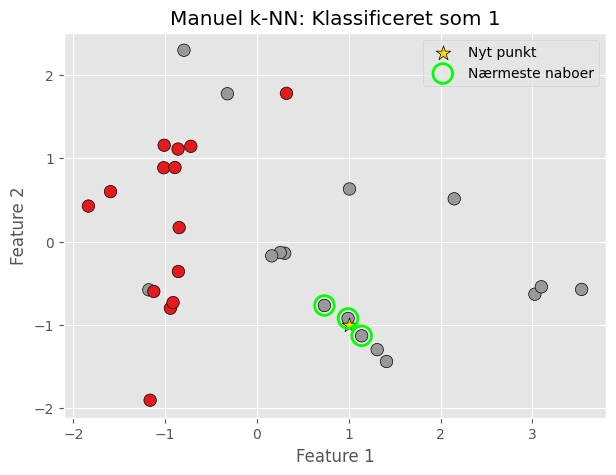

In [3]:
# Simpelt 2D eksempel med k-NN (manuel kode)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Brug scikit-learn til at lave simple 2D data
X_all, y_all = make_classification(n_samples=30,n_features=2, n_redundant=0)

# Funktion til at forudsige klassen for et punkt med k-NN (manuel)
def manual_knn_predict(X_train, y_train, new_point, k=3):
    distances = np.sqrt(np.sum((X_train - new_point)**2, axis=1))
    nearest_idx = np.argsort(distances)[:k]
    votes = y_train[nearest_idx]
    predicted_class = np.argmax(np.bincount(votes))
    return predicted_class, nearest_idx


plt.figure(figsize=(7,5))
plt.scatter(X_all[:, 0], X_all[:, 1], c=y_all, cmap=plt.cm.Set1, edgecolor='k', s=80)

# Eksempel: klassificér et nyt punkt
new_point = np.array([1, -1])
pred_class, nearest_idx = manual_knn_predict(X_all, y_all, new_point, k=3)
plt.scatter(new_point[0], new_point[1], c='gold', edgecolor='black', s=120, marker='*', label='Nyt punkt')
plt.scatter(X_all[nearest_idx,0], X_all[nearest_idx,1], facecolors='none', edgecolors='lime', s=200, linewidths=2, label='Nærmeste naboer')
plt.title(f'Manuel k-NN: Klassificeret som {pred_class}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## Interaktivt k-NN eksempel: Flyt et punkt og se klassifikation

Her kan du flytte et nyt punkt rundt i 2D og se, hvilke k naboer der vælges, og hvilken klasse punktet får.

- Se `files/interactive_classification.py`

# Indlæs og udforsk data

Vi bruger brystkræftdatasættet fra scikit-learn til at demonstrere k-NN klassifikation, beslutningsgrænser og modelevaluering.

In [4]:
# Import libraries

from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
print("Data Keys:", list(data.keys()))
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Target names: {data.target_names}")
print(f"Feature names: {data.feature_names[:5]} ...")

Data Keys: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
Features shape: (569, 30)
Labels shape: (569,)
Target names: ['malignant' 'benign']
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness'] ...


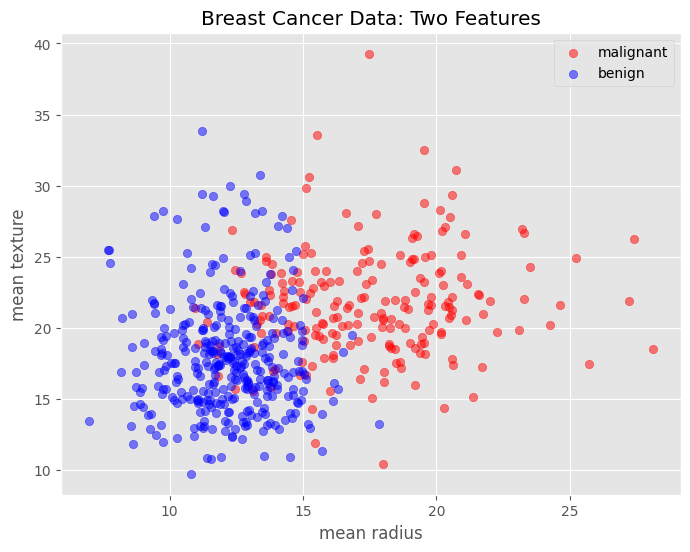

In [5]:

import matplotlib.pyplot as plt
# Select two features for visualization
feature_x = 0  # mean radius
feature_y = 1  # mean texture

plt.figure(figsize=(8,6))
for label, color, name in zip([0,1], ['red', 'blue'], data.target_names):
    plt.scatter(X[y==label, feature_x], X[y==label, feature_y],
                label=name, alpha=0.5, c=color)
plt.xlabel(data.feature_names[feature_x])
plt.ylabel(data.feature_names[feature_y])
plt.title('Breast Cancer Data: Two Features')
plt.legend()
plt.show()

# Hvorfor splitte data i træning og test?


- Testdata simulerer nye, usete data.
- Vi undgår at modellen bare "husker" træningsdata (overfitting).
- Giver et ærligt billede af modellens præstation i praksis.
- Tester om modellen kan generalisere til nye data.

In [6]:

from sklearn.model_selection import train_test_split
# Step 1: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training samples: {X_train.shape}")
print(f"Test samples: {X_test.shape}")

Training samples: (398, 30)
Test samples: (171, 30)


# Scikit-learns k-NN
>```python
>from sklearn.neighbors import KNeighborsClassifier
>model = KNeighborsClassifier(n_neighbors=3)
>model.fit(X, y)
>y_pred = model.predict(X_test)
>```

<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">

# Øvelse: Kaffe, Kage og Klynger – KNN på brystkræftdata ☕🍰

**Filnavn-forslag:** `ex_kaffeklynge.py`

### Scenarie
Du arbejder i en lettere kaotisk (men sjov) virksomhed. Du får ofte mærkelige opgaver – men i dag er det faktisk spændende! Du er blevet bedt om at undersøge, hvordan man kan bruge maskinlæring til at klassificere brystkræft baseret på data fra scikit-learn.

### Hvad du ved:
- Hvad supervised learning er, og hvorfor vi splitter data i træning/test
- Hvordan k-NN virker, og hvordan man bruger det til klassifikation
- At det er vigtigt at teste på usete data for at vurdere generalisering

### Opgave
- Brug kun de første to features fra `breast_cancer` datasættet fra scikit-learn.
- Del data i trænings- og testdata.
- Træn en k-NN model og predikter på testdata.
    - Hvor mange % af testdata klassificeres korrekt?
- Overvej: Hvilke features ville du ellers vælge, hvis du måtte vælge frit?

*Hold det simpelt – prøv dig frem og hav det sjovt! Vi kommer til at arbejde med analyser af modelperformance om lidt, så ikke brug for meget tid på det.*
</div>


<div style="background-color: rgba(200, 240, 200, 0.3); padding: 20px; border-radius: 10px; border-left: 5px solid #66bb6a;">

# Svarforslag med kode og resultater


Nøjagtighed: 0.88
Confusion matrix:
[[ 49  14]
 [  7 101]]


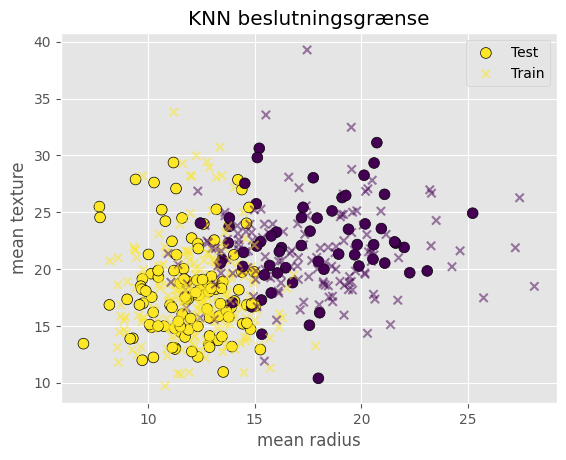

In [7]:



from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Indlæs data og brug kun de to første features
cancer = load_breast_cancer()
X = cancer.data[:, :2]
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Nøjagtighed: {acc:.2f}")
print(f"Confusion matrix:\n{cm}")

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='k', s=60, label='Test')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker='x', alpha=0.5, label='Train')
plt.title('KNN beslutningsgrænse')
plt.xlabel(cancer.feature_names[0])
plt.ylabel(cancer.feature_names[1])
plt.legend()
plt.show()



# Visualisering af Beslutningsgrænsen 
Det kan nogle gange være en stor hjælp at se hvad beslutningsgrænsen er.

>```python
># Visualisér beslutningsgrænse
>def beslutningsgraense2d(X,model, feature_columns =[0,1]):
>    buffer = 0.1
>    x_min, x_max = X[:, feature_columns[0]].min(), X[:, feature_columns[0]].max()
>    y_min, y_max = X[:, feature_columns[1]].min() , X[:, feature_columns[1]].max()
>    x_span = x_max-x_min
>    y_span = y_max-y_min
>    xx, yy = np.meshgrid(np.linspace(x_min-buffer*x_span, x_max+buffer*x_span, 100), np.linspace(y_min-buffer*y_span, y_max+buffer*y_span, 100))
>    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) # ravel betyder gør det til 1D array, c_ betyder concatenate column-wise
>    Z = Z.reshape(xx.shape)
>    return xx,yy,Z
>xx,yy,Z = beslutningsgraense2d(X_test,knn)
>plt.contourf(xx, yy, Z, alpha=0.3)
>```


Nøjagtighed: 0.88
Confusion matrix:
[[ 49  14]
 [  7 101]]


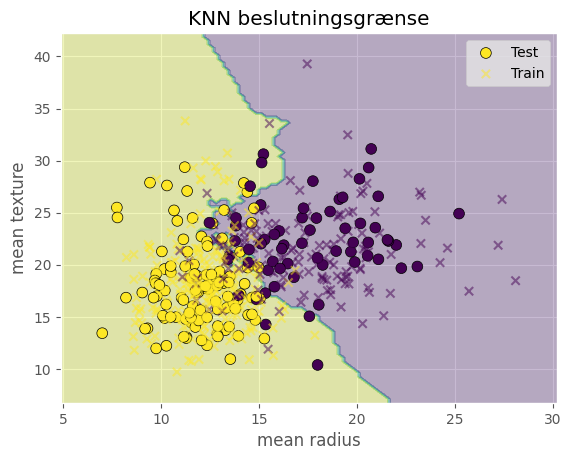

In [14]:



from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Indlæs data og brug kun de to første features
cancer = load_breast_cancer()
X = cancer.data[:, :2]
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Nøjagtighed: {acc:.2f}")
print(f"Confusion matrix:\n{cm}")

# Visualisér beslutningsgrænse
def beslutningsgraense2d(X,model, feature_columns =[0,1]):
    buffer = 0.1
    x_min, x_max = X[:, feature_columns[0]].min(), X[:, feature_columns[0]].max()
    y_min, y_max = X[:, feature_columns[1]].min() , X[:, feature_columns[1]].max()
    x_span = x_max-x_min
    y_span = y_max-y_min
    xx, yy = np.meshgrid(np.linspace(x_min-buffer*x_span, x_max+buffer*x_span, 100), np.linspace(y_min-buffer*y_span, y_max+buffer*y_span, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) # ravel betyder gør det til 1D array, c_ betyder concatenate column-wise
    Z = Z.reshape(xx.shape)
    return xx,yy,Z
    
xx,yy,Z = beslutningsgraense2d(X,knn)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='k', s=60, label='Test')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker='x', alpha=0.5, label='Train')
plt.title('KNN beslutningsgrænse')
plt.xlabel(cancer.feature_names[0])
plt.ylabel(cancer.feature_names[1])
plt.legend()
plt.show()




## Evaluering af modelpræstation ved hjælp af **Confusion Matrix**


- **Nøjagtighed (accuracy):** Andel af korrekte forudsigelser
- **Præcision (precision):** Hvor mange af de positive forudsigelser var rigtige?
- **Sensitivitet (recall/sensitivity):** Hvor mange af de sande positive blev fundet? (også kaldet "recall")
- **Specificitet (specificity):** Hvor mange af de sande negative blev fundet?

Disse mål beregnes ud fra en **confusion matrix** (forvirringsmatrix).

Vi kan bruge `sklearn.metrics` til at beregne dem.

# Confusion matrix – hvad er det?


- En **confusion matrix** (forvirringsmatrix) viser, hvordan en klassifikationsmodel klarer sig på testdata.
- Den sammenligner de sande klasser (faktiske) med modellens forudsigelser.


|                | **Forudsagt positiv** | **Forudsagt negativ** |
|----------------|------------------|------------------|
| **Målt positiv** | True Positive (TP)   | False Negative (FN)  |
| **Målt negativ** | False Positive (FP)  | True Negative (TN)   |


- Bruges til at beregne mål som sensitivitet og specificitet.

## I python
>```python
>from sklearn.metrics import confusion_matrix
>cm = confusion_matrix(y_test, y_pred)
>tn, fp, fn, tp = cm.ravel()
>```

<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">

# Øvelse: hvad Betyder TP, TN, FP, FN?

**Dette er en samtaleøvelse!** WHAT? I know right!

- Gå sammen to og to eller i små grupper.
- Diskutér, hvad de fire begreber betyder i en confusion matrix:
    - **TP** (True Positive)
    - **TN** (True Negative)
    - **FP** (False Positive)
    - **FN** (False Negative)
- Brug evt. eksemplet med brystkræftdata: Hvad betyder det, hvis en patient er TP, TN, FP eller FN?
- Skriv jeres forklaringer ned, og vær klar til at dele med resten af holdet.

*Tip: Tænk på "positiv" og "negativ" som "syg" og "rask" i denne kontekst.*


## Svar:

- **TP (True Positive):** Modellen forudsiger positiv (fx syg), og det er korrekt – personen er faktisk syg.
- **TN (True Negative):** Modellen forudsiger negativ (fx rask), og det er korrekt – personen er faktisk rask.
- **FP (False Positive):** Modellen forudsiger positiv (fx syg), men det er forkert – personen er faktisk rask ("falsk alarm").
- **FN (False Negative):** Modellen forudsiger negativ (fx rask), men det er forkert – personen er faktisk syg ("overset sygdom").

*I konteksten af brystkræftdata:*
- **TP:** En patient med kræft bliver korrekt klassificeret som syg.
- **TN:** En rask patient bliver korrekt klassificeret som rask.
- **FP:** En rask patient bliver fejlagtigt klassificeret som syg (unødvendig bekymring/test).
- **FN:** En patient med kræft bliver fejlagtigt klassificeret som rask (farligt, da sygdommen overses).



*I konteksten af billedsegmentering (fx forgrund/baggrund):*
- **TP:** Et pixel, der faktisk tilhører forgrunden (fx et objekt), bliver korrekt klassificeret som forgrund.
- **TN:** Et pixel, der faktisk tilhører baggrunden, bliver korrekt klassificeret som baggrund.
- **FP:** Et pixel, der faktisk tilhører baggrunden, bliver fejlagtigt klassificeret som forgrund ("falsk forgrund").
- **FN:** Et pixel, der faktisk tilhører forgrunden, bliver fejlagtigt klassificeret som baggrund ("overset forgrund").


# Sensitivitet (Recall)


- **Sensitivitet** (også kaldet *recall*) måler hvor stor en andel af de sande positive, som modellen korrekt finder.
- Formel:  
  $$\text{Sensitivitet} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$$


- I confusion matrixen: Hvor mange af de faktiske positive (syge) bliver korrekt klassificeret som positive?

## I Python
>```python
>from sklearn.metrics import recall_score
>recall = recall_score(y_test, y_pred)
>```

# Specificitet


- **Specificitet** måler hvor stor en andel af de sande negative, som modellen korrekt finder.
- Formel:  
  $$\text{Specificitet} = \frac{\text{True Negatives}}{\text{True Negatives} + \text{False Positives}}$$


- I confusion matrixen: Hvor mange af de faktiske negative (raske) bliver korrekt klassificeret som negative?

## I Python
>```python
>specificity = tn / (tn + fp)
>```

# Python-kode til confusion matrix, sensitivitet og specificitet, samlet

In [9]:
# Beregn og vis forskellige præstationsmål
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier


def print_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred)
    specificity = tn / (tn + fp)
    print(f"Nøjagtighed (accuracy): {accuracy:.2f}")
    print(f"Præcision (precision): {precision:.2f}")
    print(f"Sensitivitet (recall/sensitivity): {sensitivity:.2f}")
    print(f"Specificitet (specificity): {specificity:.2f}")
    print(f"Confusion matrix:\n{cm}")

model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print_metrics(y_test, y_pred)

Nøjagtighed (accuracy): 0.88
Præcision (precision): 0.90
Sensitivitet (recall/sensitivity): 0.92
Specificitet (specificity): 0.83
Confusion matrix:
[[52 11]
 [ 9 99]]


# Visualizering af confusion matrix

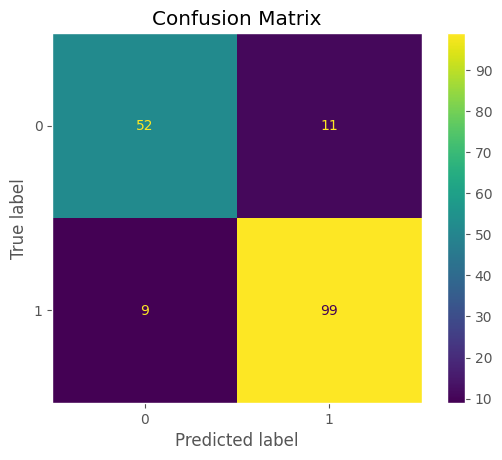

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('Confusion Matrix')
plt.grid(False)  # Fjern gitterlinjer for bedre læsbarhed
plt.show()

# Exercises


<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">

# Øvelse: KNN vs. KMeans på brystkræftdata

**Filnavn-forslag:** `ex_knn_vs_kmeans_breast_cancer.py`

### Scenarie
Martin  har fået et nyt job som chef-dataanalytiker i det fiktive firma "Klyng & Krammer A/S". 
Martin er kendt for at drikke alt for meget kaffe og for at have lidt for stor tiltro til både maskinlæring og sin samling af gule post-its. 
En dag kommer Martin løbende ind i kontoret, vifter med armene og råber:

> "Vi skal bruge både KNN og KMeans til at forudsige brystkræft! I må kun bruge de 2 første features, ellers kan jeg ikke tegne det på mit whiteboard!"

Martin insisterer på, at I sammenligner de to metoder – og at I bagefter fortæller ham, hvorfor KMeans måske ikke er det bedste valg (selvom han allerede har skrevet det på en post-it).

### Hvad du ved:
- Hvordan man indlæser og forbehandler data fra scikit-learn
- Hvordan man træner og evaluerer KNN og KMeans

### Opgave
- Indlæs brystkræftdatasættet fra scikit-learn (`load_breast_cancer`).
- Brug kun de to første features til visualisering af data.
- Split data i trænings- og testdata.
- Træn en KNN-klassifikationsmodel og evaluer nøjagtighed, recall og confusion matrix på testdata.
- Træn en KMeans-model med to klynger på træningsdata, og brug klyngecentrene til at klassificere testdata (tildel klassen baseret på nærmeste center). Evaluer på samme måde.
- Visualisér beslutningsgrænser og diskuter forskellen på de to metoder – og fortæl Martin, hvorfor han måske skal holde sig til KNN (og kaffe).

</div>



<div style="background-color: rgba(200, 240, 200, 0.3); padding: 20px; border-radius: 10px; border-left: 5px solid #66bb6a;">

# Svarforslag med kode og resultater

Typisk vil KNN have væsentligt højere nøjagtighed og recall end KMeans på denne opgave, fordi KMeans ikke bruger labels og kun grupperer efter afstand.


KNN nøjagtighed: 0.88
KNN recall: 0.94
KNN confusion matrix:
[[ 49  14]
 [  7 101]]
KMeans nøjagtighed: 0.82
KMeans recall: 0.81
KMeans confusion matrix:
[[53 10]
 [20 88]]


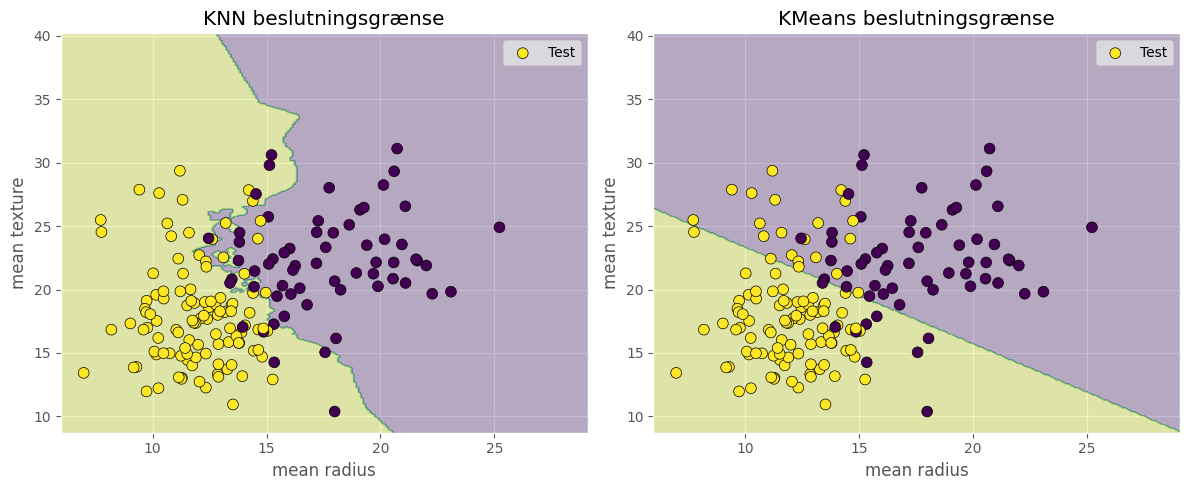

In [11]:

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Indlæs data og brug kun de to første features
cancer = load_breast_cancer()
X = cancer.data[:, :2]
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print(f"KNN nøjagtighed: {acc_knn:.2f}")
print(f"KNN recall: {recall_knn:.2f}")
print(f"KNN confusion matrix:\n{cm_knn}")

# KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train)
y_pred_kmeans = kmeans.predict(X_test)
# Match labels if necessary
if np.sum(y_pred_kmeans == y_test) < np.sum(1 - y_pred_kmeans == y_test):
    y_pred_kmeans = 1 - y_pred_kmeans
acc_kmeans = accuracy_score(y_test, y_pred_kmeans)
recall_kmeans = recall_score(y_test, y_pred_kmeans)
cm_kmeans = confusion_matrix(y_test, y_pred_kmeans)

print(f"KMeans nøjagtighed: {acc_kmeans:.2f}")
print(f"KMeans recall: {recall_kmeans:.2f}")
print(f"KMeans confusion matrix:\n{cm_kmeans}")

# Visualisering af beslutningsgrænser (Behov ikke at kunne, bare for at se konceptet)
h = .1
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

plt.figure(figsize=(12,5))
# KNN
plt.subplot(1,2,1)
Z_knn = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z_knn, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='k', s=60, label='Test')
plt.title('KNN beslutningsgrænse')
plt.xlabel(cancer.feature_names[0])
plt.ylabel(cancer.feature_names[1])
plt.legend()
# KMeans
plt.subplot(1,2,2)
Z_kmeans = kmeans.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z_kmeans, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor='k', s=60, label='Test')
plt.title('KMeans beslutningsgrænse')
plt.xlabel(cancer.feature_names[0])
plt.ylabel(cancer.feature_names[1])
plt.legend()
plt.tight_layout()
plt.show()




<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">

# Øvelse: Månekrig – KNN vs. KMeans på kunstige data

**Filnavn-forslag:** `ex_knn_vs_kmeans_moons.py`

### Scenarie
Martin har nu fået den geniale idé, at I skal segmentere måneformede data – for "det er jo næsten som at segmentere osteskiver!" 
Han insisterer på, at I både bruger KMeans (fordi han synes, det lyder sejt) og KNN (fordi det faktisk virker). 
Han lover en ekstra kop kaffe til den gruppe, der kan vise ham, hvorfor KNN vinder på måne-data!

### Opgave
- Generér et datasæt med to ikke-lineært separable klasser med `make_moons` fra scikit-learn.
- Visualisér datasættet (farv punkterne efter klasse).
- Split data i trænings- og testdata.
- Træn og anvend KMeans (to klynger) på træningsdata, og brug det til at segmentere testdata.
- Træn og anvend KNN på samme data.
- Visualisér segmenteringen for begge metoder (farv punkterne efter forudsagt klasse).
- Sammenlign nøjagtighed og confusion matrix for KMeans og KNN på testdata.
- Forklar, hvorfor KNN klarer sig bedre på dette datasæt.


>```python
>from sklearn.datasets import make_moons
>from sklearn.model_selection import train_test_split
>import matplotlib.pyplot as plt
>import numpy as np
>
># Generér data
>X, y = make_moons(n_samples=3000, noise=0.25, random_state=42)
>plt.figure(figsize=(5,5))
>plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
>plt.title('Moons data')
>plt.show()
>
>X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
```





<div style="background-color: rgba(200, 240, 200, 0.3); padding: 20px; border-radius: 10px; border-left: 5px solid #66bb6a;">

# Svarforslag med kode og resultater


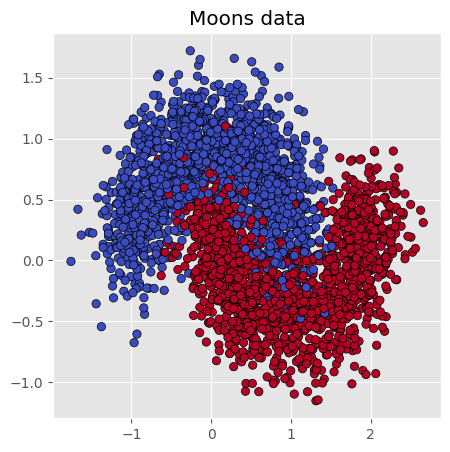

KMeans nøjagtighed: 0.75
KNN nøjagtighed: 0.93
KMeans confusion matrix:
[[354 116]
 [106 324]]
KNN confusion matrix:
[[440  30]
 [ 33 397]]


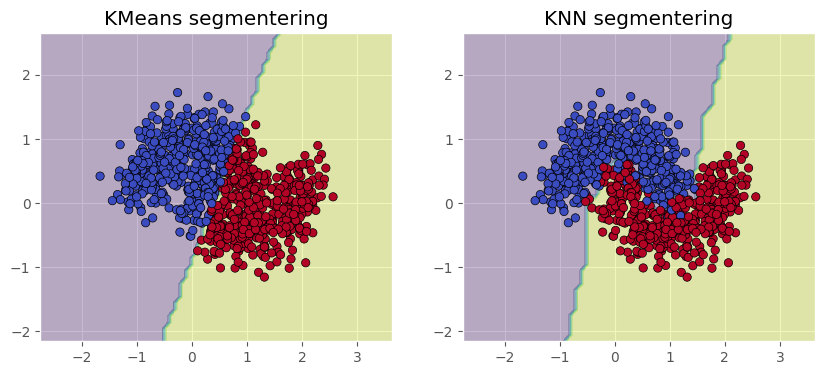

In [12]:


from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Generér data
X, y = make_moons(n_samples=3000, noise=0.25, random_state=42)
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.title('Moons data')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train)
y_pred_kmeans = kmeans.predict(X_test)
if np.sum(y_pred_kmeans == y_test) < np.sum(1 - y_pred_kmeans == y_test):
    y_pred_kmeans = 1 - y_pred_kmeans
acc_kmeans = accuracy_score(y_test, y_pred_kmeans)
cm_kmeans = confusion_matrix(y_test, y_pred_kmeans)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print(f"KMeans nøjagtighed: {acc_kmeans:.2f}")
print(f"KNN nøjagtighed: {acc_knn:.2f}")
print(f"KMeans confusion matrix:\n{cm_kmeans}")
print(f"KNN confusion matrix:\n{cm_knn}")

# Visualisering af segmentering
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('KMeans segmentering')
# Visualisér beslutningsgrænse
h = .1
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()]) # ravel betyder gør det til 1D array, c_ betyder concatenate column-wise
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_kmeans, cmap='coolwarm', edgecolor='k')
plt.subplot(1,2,2)
plt.title('KNN segmentering')
# Visualisér beslutningsgrænse
h = .1
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]) # ravel betyder gør det til 1D array, c_ betyder concatenate column-wise
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_knn, cmap='coolwarm', edgecolor='k')
plt.show()
